# Fixed point optimization of a cubic function

In this lab, we implement a fixed-point version of a monic cubic function:

```python
   y = x**3 + a[2]*x**2 + a[1]*x + a[0]
```

We will follow the similar sequence of steps as the [fixed point demo](https://sdrangan.github.io/hwdesign/docs/demos/fixp/).

## Floating Point Version

We begin by writing a floating point version of the function.

In [1]:
import numpy as np
from numpy.typing import NDArray

def cubic_float(
    x: NDArray[np.float64],  # shape (n,)
    a: NDArray[np.float64],  # shape (n, 3)
) -> NDArray[np.float64]:
    """
    Evaluate a monic cubic polynomial at points x:

        y = a[:,0] + a[:,1] * x + a[:,2] * x**2 +  x**3
    """
    y = a[:,0] + a[:,1] * x + a[:,2] * x**2 + x**3
    return y

To illustrate, we plot the function for some values:


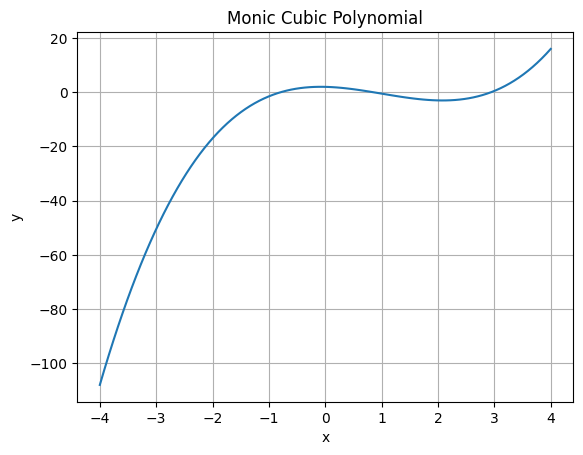

In [2]:
nplot = 100
xplot = np.linspace(-4.0, 4.0, nplot)
aplot = np.array([2.0, -0.5, -3.0])
aplot = aplot[None,:].repeat(nplot, axis=0)

yplot = cubic_float(xplot, aplot)
import matplotlib.pyplot as plt
plt.plot(xplot, yplot)
plt.title("Monic Cubic Polynomial")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

## Create a Fixed Point Version

We now create a fixed point version. THere are several ways to handle overflow.
One way is to saturate after each product.  For example, suppose that `xint`
is the integer representation of `x` in `Q(wid,fbits)`.  We can implement the
product such as `xint*xint`, as follows:

```python
x2int = saturate((xint * xint) >> fbits, wid)
```

This product `(xint * xint) >> fbits` will be in `Q(wid2, fbits)` where
`wid2= 2*wid-fbits`.   We then saturate each product back to `wid` bits.

Similarly, we can use:

```python
x3int = saturate((xint * x2int) >> fbits, wid_acc)
```

to get the cubic term.  Use this pattern to complete the following code.

In [3]:
import sys
if "google.colab" in sys.modules:
    !pip install git+https://github.com/sdrangan/hwdesign.git

from xilinxutils.fixputils import truncate, saturate

  Cloning https://github.com/sdrangan/hwdesign.git to /tmp/pip-req-build-a0v5l4jz
  Running command git clone --filter=blob:none --quiet https://github.com/sdrangan/hwdesign.git /tmp/pip-req-build-a0v5l4jz
  Resolved https://github.com/sdrangan/hwdesign.git to commit d108e35126dc90feefe0c96cd143f4d6d10e889f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for xilinxutils: filename=xilinxutils-0.1.1.dev198+gd108e3512-py3-none-any.whl size=34942 sha256=25488896a4f1577f37c631281893fabae914d24ae5d7ccaa7799e037295672d8
  Stored in directory: /tmp/pip-ephem-wheel-cache-vmstg0az/wheels/e3/07/c8/1935a31d5ccd499ac8332cf1fdbfebaf3ee0429bdeeb430f46
Successfully built xilinxutils


In [ ]:
def cubic_fixed(
        xint : NDArray[np.int64],  # shape (n,)
        aint : NDArray[np.int64],  # shape (n, 4)
        wid : int = 16,   # total bit width
        fbits : int = 8
    ) -> NDArray[np.int64]:
    """
    Evaluate a monic cubic polynomial in fixed point:
        y = a[:,0] + a[:,1] * x + a[:,2] * x**2 + x**3


    Parameters
    ----------
    xint : NDArray[np.int64]
        Input values in Q(wid, fbits), shape (n,)
    aint : NDArray[np.int64]
        Coefficients in Q(wid, fbits), shape (n, deg+1) where deg=3
    wid : int
        Total bit width of inputs and outputs
    fbits : int
        Number of fractional bits in inputs and outputs


    Returns
    -------
    yint : NDArray[np.int64]
        Output values in Q(wid, fbits), shape (n,)
    """

    # TODO: Implement fixed-point cubic evaluation.
    # Use the saturate function after each product and sum to ensure
    # that intermediate values do not exceed the specified bit width.
    # Hint: You will need to compute the following intermediate values:
    #   x2int = ...
    #   x3int = ...
    #   yint = ...

    x2int = saturate((xint * xint) >> fbits, wid)
    x3int = saturate((xint * x2int) >> fbits, wid)
    a2x2 = saturate((aint[:, 2] * x2int) >> fbits, wid)
    a1x1 = saturate((aint[:, 1] * xint) >> fbits, wid)
    yint = saturate(aint[:, 0] + a1x1, wid)
    yint = saturate(yint + a2x2, wid)
    yint = saturate(yint + x3int, wid)

    return yint





Now plot a comparison of the the floating and fixed point function over the set of values xplot.
This part will not be submitted, but it will help you make sure that your algorithm is working correctly.
You should see:

- For `wid=16`, `fbits=8`, the floating and fixed point versions match well over this range of inputs
- For `wid=16`, `fbits=12`, the fixed point version clearly saturates


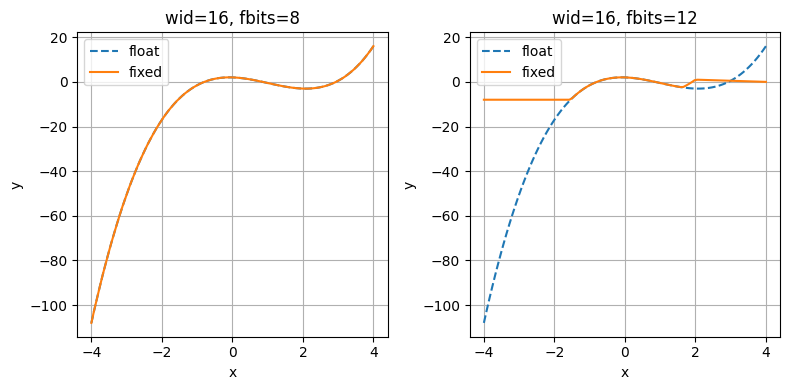

In [ ]:
# Bit widths to test
wid_plot = [16, 16]
fbits_plot = [8, 12]
nwid = len(wid_plot)


plt.subplots(1, nwid,figsize=(4*nwid, 4))

for i in range(nwid):

    # TODO: Compute fixed-point outputs for this bit width
    #   xplot_int = ...
    #   aplot_int = ...
    #   yplot_int = ...
    #   yplot_fix = ...



    # TODO:  Plot the fixed and floating point results in a subplot
    #  plt.subplot(...)
    #  plt.plot(...)
    wid = wid_plot[i]
    fbits = fbits_plot[i]

    xplot_int = np.round(xplot * (2**fbits)).astype(np.int64)
    aplot_int = np.round(aplot * (2**fbits)).astype(np.int64)
    yplot_int = cubic_fixed(xplot_int, aplot_int, wid=wid, fbits=fbits)
    yplot_fix = yplot_int / (2**fbits)
    plt.subplot(1, nwid, i+1)
    plt.plot(xplot, yplot, label='float', linestyle='--')
    plt.plot(xplot, yplot_fix, label='fixed')

    plt.title(f"wid={wid}, fbits={fbits}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

## Generate Test Vectors

As in the demo, you could optimize the bit widths.  But, we skip this step.  Here we just generate test vectors.  We will generate two test vectors:

- `test_vectors/tv_w16_f8.csv` for `wid=16` and `fbits=8`.  In this test case, there are no overflows.
This test case will ensure that the regular logic in the SV implmentation matches the python implementation.
- `test_vectors/tv_w16_f12.csv` for `wid=16` and `fbits=12`.  In this test case, there is significant overflow.  
The test case will good to test the SV implementation performs overflow exactly in a manner that the python implementation does.

The test also measures the MSE:  You should see approximately the following values.
Specifically, with `fbits=8`, you get a very good approximation, but with `fbits=12`,
the logic begins to saturate.

| W (Total Bits) | F (Fraction Bits) | Expected MSE      |
|----------------|-------------------|-------------------|
| 16             | 8                 | ~1e-5       |
| 16             | 12                | ~0.2              |



In [6]:
import os
import pandas as pd

# Create test_vectors directory if it doesn't exist
os.makedirs('test_outputs', exist_ok=True)

# Generate random samples
nsamp = 100
deg = 3
a = np.random.uniform(-4.0, 4.0, (nsamp, deg))
x = np.random.uniform(-2.0, 2.0, nsamp)

# Fix parameters for test vector generation
wid_acc = 32
wid = 16
fbits_test = [8, 12]

for fbits in fbits_test:
    print(f'\nGenerating test vectors for W={wid}, F={fbits}')

    # TODO: Generate test vectors
    #   y = floating point output
    #   xint = fixed point input x
    #   aint = fixed point input a
    #   yint = fixed point output
    #   yfix = fixed point output back converted to float

    # Compute floating point output
    y = cubic_float(x, a)

    # Convert to fixed point representation of inputs
    xint = np.round(x * (2**fbits)).astype(np.int64)
    aint = np.round(a * (2**fbits)).astype(np.int64)

    # Compute fixed point outputs
    yint = cubic_fixed(
        xint=xint,
        aint=aint,
        wid=wid,
        fbits=fbits)
    yfix = yint.astype(np.float64) / (2**fbits)

    mse = np.mean((y - yfix)**2)/ np.mean(y**2)
    print("Mean squared error: %12.4e" % mse)

    # Create DataFrame with all values
    df = pd.DataFrame({
        'xint': xint,
        'aint0': aint[:, 0],
        'aint1': aint[:, 1],
        'aint2': aint[:, 2],
        'y': y,
        'yint': yint,
        'yfix': yfix
    })

    # Save to CSV file
    csv_filename = f'test_outputs/tv_w{wid}_f{fbits}.csv'
    df.to_csv(csv_filename, index=False)
    print(f"Test vectors saved to {csv_filename}")
    print(f"Number of test vectors: {len(df)}")
    print(f"\nFirst 5 rows:")
    print(df.head())



Generating test vectors for W=16, F=8
Mean squared error:   4.3869e-06
Test vectors saved to test_outputs/tv_w16_f8.csv
Number of test vectors: 100

First 5 rows:
   xint  aint0  aint1  aint2         y  yint      yfix
0  -296    324   -983    767  8.164672  2088  8.156250
1   353    935    901   -356  8.480636  2171  8.480469
2  -164   -644   -213   -200 -2.568212  -659 -2.574219
3  -175    505   -200    820  3.690508   940  3.671875
4     0    209   -638    885  0.815090   209  0.816406

Generating test vectors for W=16, F=12
Mean squared error:   1.7356e-01
Test vectors saved to test_outputs/tv_w16_f12.csv
Number of test vectors: 100

First 5 rows:
   xint  aint0  aint1  aint2         y   yint      yfix
0 -4736   5189 -15721  12272  8.164672  26435  6.453857
1  5650  14953  14411  -5701  8.480636  32669  7.975830
2 -2625 -10311  -3413  -3206 -2.568212 -10519 -2.568115
3 -2807   8084  -3198  13115  3.690508  15114  3.689941
4     0   3339 -10213  14155  0.815090   3339  0.815186
